In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Nov 26 20:30:39 2024
@author: marriyapillais
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Plot format

colors = {
    "BAU" : "#0A0AFF",   # blue
    "REC" : "#2CE084",   # light green
    "CIR" : "#117542",    # green
    }
colors_muted = {
    "BAU" : "#ACACFC",   # blue
    "REC" : "#A8DBC1",   # light green
    "CIR" : "#627E70",    # green
    }

labels_m = net.index.to_list()     # materials

x = np.arange(len(labels_m))
width = 0.7 / len(order)

font
order = []

In [ ]:
font = 'Arial'
fontsize = 10
plt.rcParams.update({'font.size': fontsize, 'font.family': font})
cm = 1/2.54
colors = ['EE7733', '0077BB', '33BBEE', 'EE3377', 'CC3311', '009988', 'BBBBBB'] #high vibrant color style from SciencePlots

In [13]:
def plot_trends(bau_data, scenarios, columns, historic_labels, bau_labels, colors, title, ylabel):
    """
    Reusable function to plot time series trends with historic points, BAU lines, and one or more scenarios.
    
    Parameters:
    - bau_data: DataFrame for BAU scenario
    - scenarios: list of tuples (scenario_data, scenario_labels, line_style)
    - columns: list of column names to plot
    - historic_labels: list of labels for historic data points
    - bau_labels: list of labels for BAU trend lines
    - colors: list of colors for each column
    - title: plot title
    - ylabel: y-axis label
    """
    for col_idx, (col, h_label, b_label, color) in enumerate(zip(columns, historic_labels, bau_labels, colors)):
        # Historic points (up to 2021)
        plt.plot(bau_data.loc[bau_data['TIME'] <= 2021]['TIME'],
                 bau_data.loc[bau_data['TIME'] <= 2021][col],
                 'o', label=h_label, color=color)

        # BAU trend line (2010-2050)
        x = np.arange(2010, 2051)
        plt.plot(x, bau_data[col].loc[bau_data['TIME'].isin(x)],
                 '-', label=b_label, color=color)

        # Scenario trend lines (from 2022 onwards)
        for scenario_data, scenario_labels, style in scenarios:
            plt.plot(scenario_data.loc[scenario_data['TIME'] >= 2022]['TIME'],
                     scenario_data.loc[scenario_data['TIME'] >= 2022][col],
                     style, label=scenario_labels[col_idx], color=color)

    plt.xlabel('Years')
    plt.ylabel(ylabel)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, prop={'size': 7})
    plt.title(title)
    plt.show()

### Load data

In [4]:
bau_data = pd.read_csv("../data/results/BAU_MSW.csv")
rec_data = pd.read_csv("../data/results/REC_MSW.csv")
cir_data = pd.read_csv("../data/results/CIR_MSW.csv")

In [5]:
reg_bau_data = bau_data.loc[bau_data['LOCATION']=='EU27+4']
reg_rec_data = rec_data.loc[rec_data['LOCATION']=='EU27+4']
reg_cir_data = cir_data.loc[cir_data['LOCATION']=='EU27+4']

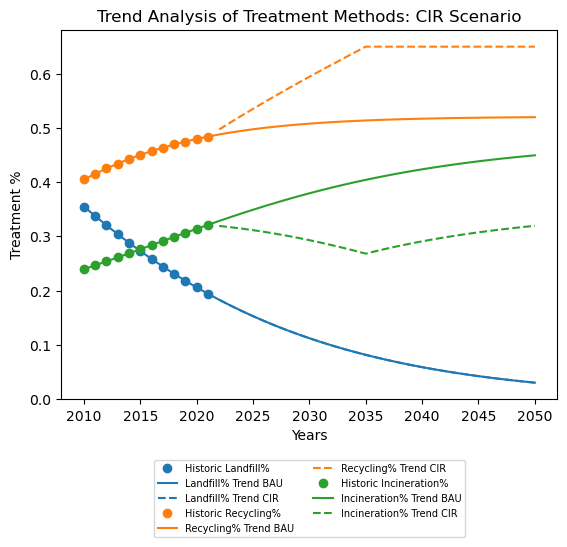

In [14]:
# Treatment methods plot
columns = ['DIS%', 'RCY%', 'INC%']
historic_labels = ['Historic Landfill%', 'Historic Recycling%', 'Historic Incineration%']
bau_labels = ['Landfill% Trend BAU', 'Recycling% Trend BAU', 'Incineration% Trend BAU']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
scenarios = [
    (reg_cir_data, ['Landfill% Trend CIR', 'Recycling% Trend CIR', 'Incineration% Trend CIR'], '--'),

]
plot_trends(reg_bau_data, scenarios, columns, historic_labels, bau_labels, colors, 'Trend Analysis of Treatment Methods: CIR Scenario', 'Treatment %')

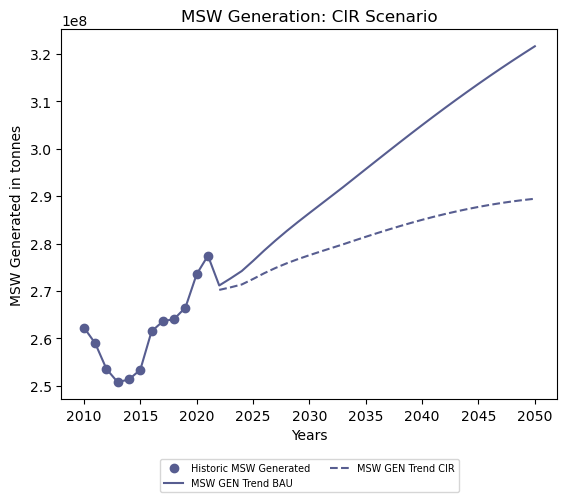

In [15]:
# MSW Generation plot
columns = ['MSW_GEN_T']
historic_labels = ['Historic MSW Generated']
bau_labels = ['MSW GEN Trend BAU']
colors = ['#575D90']
scenarios = [
    (reg_cir_data, ['MSW GEN Trend CIR'], '--'),

]
plot_trends(reg_bau_data, scenarios, columns, historic_labels, bau_labels, colors, 'MSW Generation: CIR Scenario', 'MSW Generated in tonnes')

In [ ]:
# Treatment methods plot
columns = ['DIS%', 'RCY%', 'INC%']
historic_labels = ['Historic Landfill%', 'Historic Recycling%', 'Historic Incineration%']
bau_labels = ['Landfill% Trend BAU', 'Recycling% Trend BAU', 'Incineration% Trend BAU']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
scenarios = [
    (reg_cir_data, ['Landfill% Trend CIR', 'Recycling% Trend CIR', 'Incineration% Trend CIR'], '--'),

]
plot_trends(reg_bau_data, scenarios, columns, historic_labels, bau_labels, colors, 'Trend Analysis of Treatment Methods: CIR Scenario', 'Treatment %')

In [ ]:
plt.show()

%%

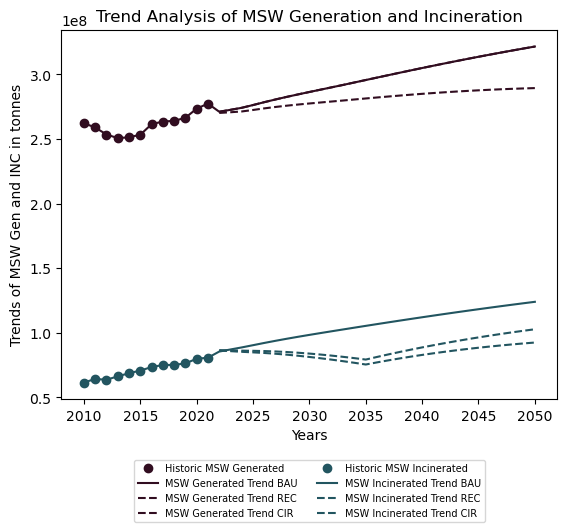

In [16]:

# MSW Generation and Incineration plot
columns = ['MSW_GEN_T', 'INC_T']
historic_labels = ['Historic MSW Generated', 'Historic MSW Incinerated']
bau_labels = ['MSW Generated Trend BAU', 'MSW Incinerated Trend BAU']
colors = ['#310D20', '#225560']
scenarios = [
    (reg_rec_data, ['MSW Generated Trend REC', 'MSW Incinerated Trend REC'], '--'),
    (reg_cir_data, ['MSW Generated Trend CIR', 'MSW Incinerated Trend CIR'], '--'),
]
plot_trends(reg_bau_data, scenarios, columns, historic_labels, bau_labels, colors, 'Trend Analysis of MSW Generation and Incineration', 'Trends of MSW Gen and INC in tonnes')

%

In [19]:
ash_data = pd.read_csv('../data/results/FutuRaM/Data_Structure_Task4.1_Task4.2_all_scenarios.csv')
reg_bau_data = ash_data.loc[(ash_data['Country']=='EU27+4')&((ash_data['Scenario']=='BAU')|(ash_data['Scenario']=='OBS'))]
reg_rec_data = ash_data.loc[(ash_data['Country']=='EU27+4')&(ash_data['Scenario']=='REC')] 
reg_cir_data = ash_data.loc[(ash_data['Country']=='EU27+4')&(ash_data['Scenario']=='CIR')]

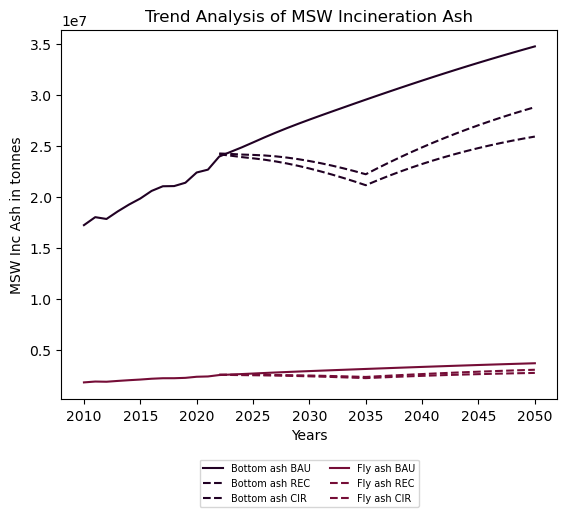

In [20]:
x = np.arange(2010,2051)
fig = plt.plot(x, reg_bau_data['Value'].loc[(reg_bau_data['Year'].isin(x))&(reg_bau_data['Substance main parent']=='19 01 11*')],'-',label = 'Bottom ash BAU', color = '#210124')
plt.plot(reg_rec_data.loc[reg_rec_data['Year']>=2022]['Year'].unique(),reg_rec_data.loc[(reg_rec_data['Year']>=2022)&(reg_rec_data['Substance main parent']=='19 01 11*')]['Value'],'--',label = 'Bottom ash REC', color = '#210124')
plt.plot(reg_cir_data.loc[reg_cir_data['Year']>=2022]['Year'].unique(),reg_cir_data.loc[(reg_cir_data['Year']>=2022)&(reg_cir_data['Substance main parent']=='19 01 11*')]['Value'],'--',label = 'Bottom ash CIR', color = '#210124')
plt.plot(x, reg_bau_data['Value'].loc[(reg_bau_data['Year'].isin(x))&(reg_bau_data['Substance main parent']=='19 01 13*')],'-',label = 'Fly ash BAU', color = '#750D37')
plt.plot(reg_rec_data.loc[reg_rec_data['Year']>=2022]['Year'].unique(),reg_rec_data.loc[(reg_rec_data['Year']>=2022)&(reg_rec_data['Substance main parent']=='19 01 13*')]['Value'],'--',label = 'Fly ash REC', color = '#750D37')
plt.plot(reg_cir_data.loc[reg_cir_data['Year']>=2022]['Year'].unique(),reg_cir_data.loc[(reg_cir_data['Year']>=2022)&(reg_cir_data['Substance main parent']=='19 01 13*')]['Value'],'--',label = 'Fly ash CIR', color = '#750D37')
plt.xlabel('Years')
plt.ylabel('MSW Inc Ash in tonnes')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, prop={'size': 7})
plt.title('Trend Analysis of MSW Incineration Ash')

plt.show()